  sentence splitting: Excluded 2 questions from metrics calculation.
  markdown splitting: Excluded 2 questions from metrics calculation.
  markdown and sentence splitting: Excluded 2 questions from metrics calculation.


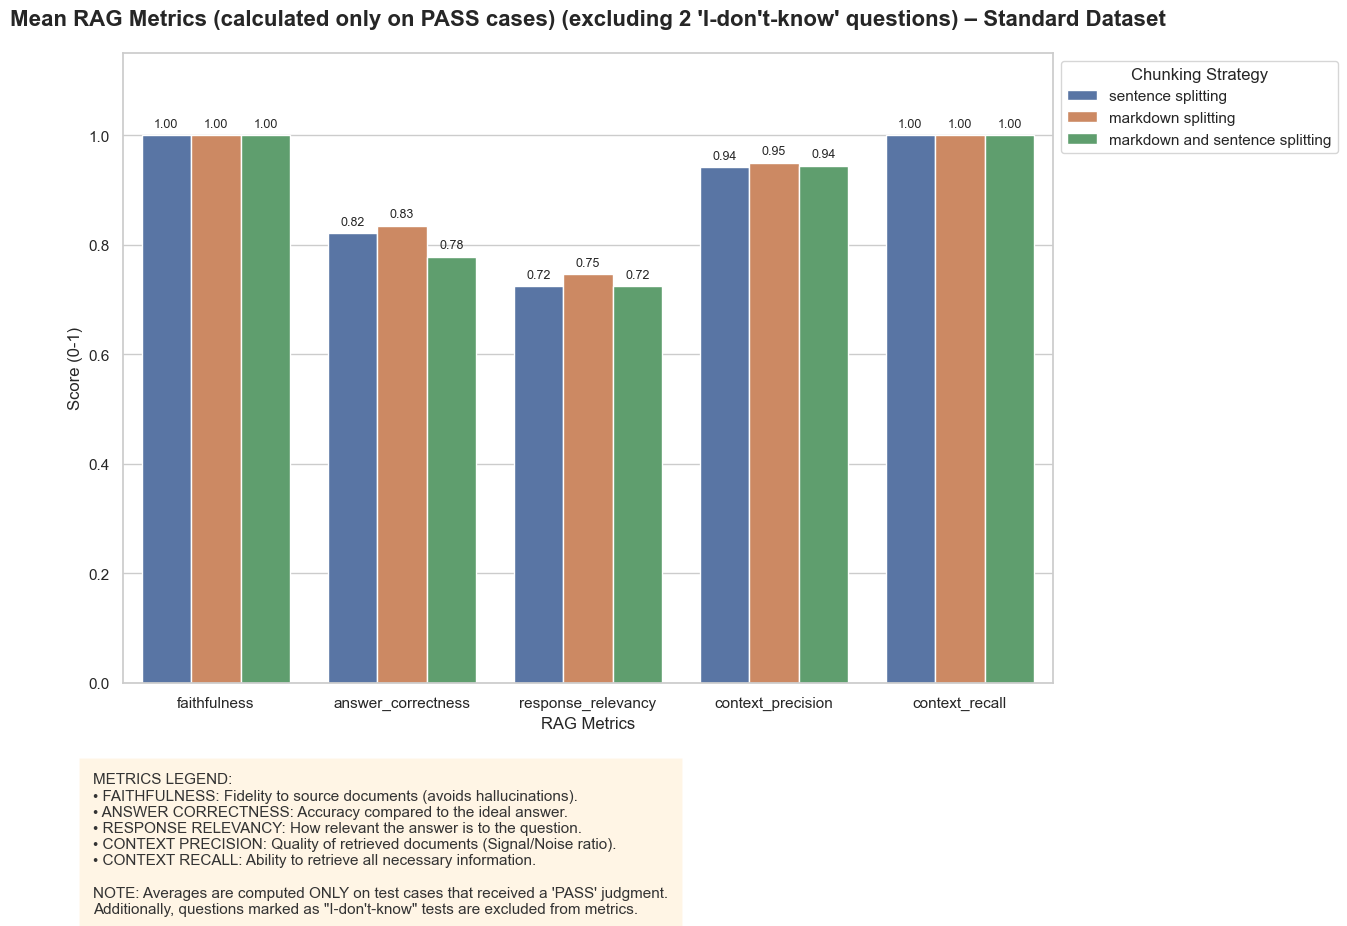

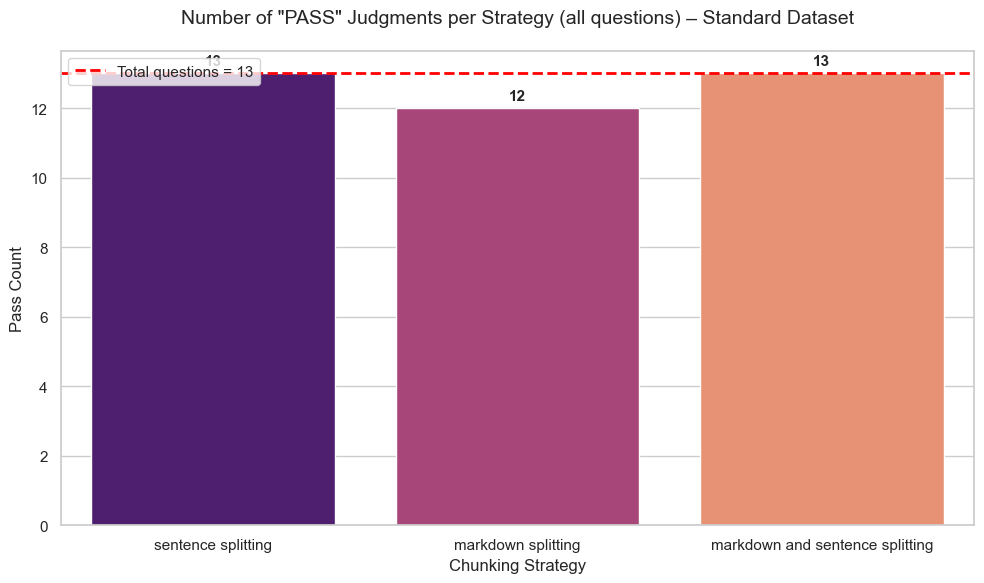


--- SUMMARY JUDGE PASS COUNT (Standard) ---
sentence splitting: 13 pass / 13 total (rate: 100.0%)
markdown splitting: 12 pass / 13 total (rate: 92.3%)
markdown and sentence splitting: 13 pass / 13 total (rate: 100.0%)

--- TEXTUAL DATA SUMMARY – METRICS AVERAGED ON PASS CASES ONLY (Standard) ---
Excluded questions: ["l aula T dell'edificio A è libera il giorno 20 marzo 2026?", 'dimmi i corsi disponibili del dipartimento di musicologia']
SENTENCE SPLITTING: faithfulness: 1.000, answer_correctness: 0.821, response_relevancy: 0.725, context_precision: 0.942, context_recall: 1.000
MARKDOWN SPLITTING: faithfulness: 1.000, answer_correctness: 0.835, response_relevancy: 0.747, context_precision: 0.950, context_recall: 1.000
MARKDOWN AND SENTENCE SPLITTING: faithfulness: 1.000, answer_correctness: 0.778, response_relevancy: 0.725, context_precision: 0.944, context_recall: 1.000


  sentence splitting: Excluded 2 questions from metrics calculation.
  markdown splitting: Excluded 2 questions fr

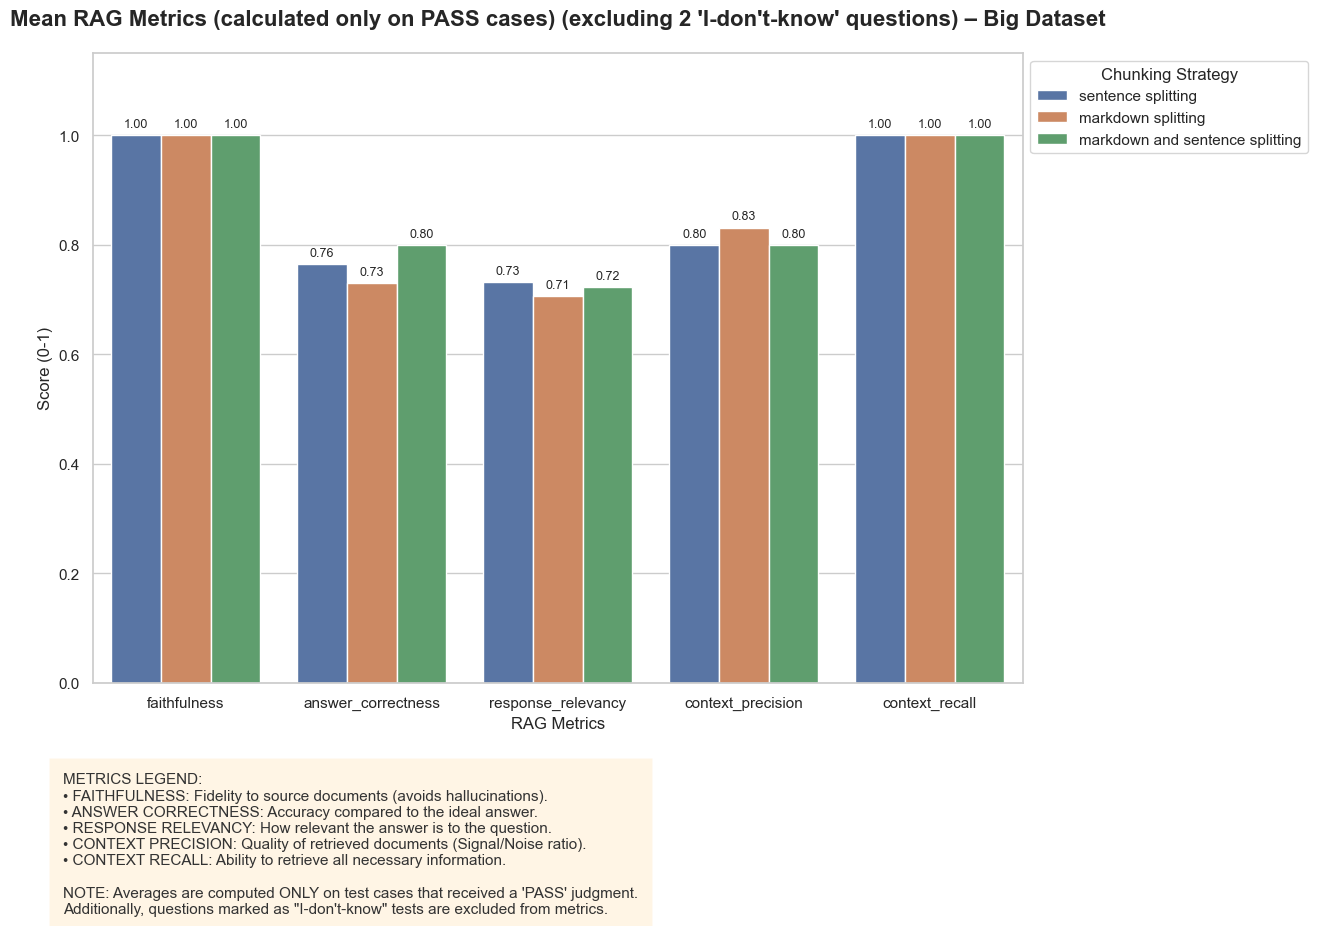

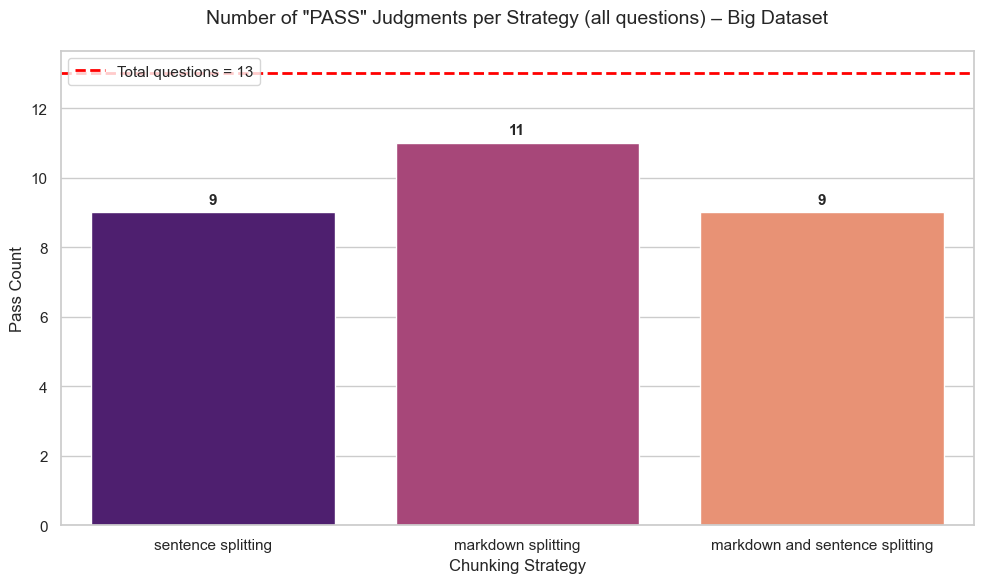


--- SUMMARY JUDGE PASS COUNT (Big) ---
sentence splitting: 9 pass / 13 total (rate: 69.2%)
markdown splitting: 11 pass / 13 total (rate: 84.6%)
markdown and sentence splitting: 9 pass / 13 total (rate: 69.2%)

--- TEXTUAL DATA SUMMARY – METRICS AVERAGED ON PASS CASES ONLY (Big) ---
Excluded questions: ["l aula T dell'edificio A è libera il giorno 20 marzo 2026?", 'dimmi i corsi disponibili del dipartimento di musicologia']
SENTENCE SPLITTING: faithfulness: 1.000, answer_correctness: 0.765, response_relevancy: 0.732, context_precision: 0.799, context_recall: 1.000
MARKDOWN SPLITTING: faithfulness: 1.000, answer_correctness: 0.730, response_relevancy: 0.706, context_precision: 0.831, context_recall: 1.000
MARKDOWN AND SENTENCE SPLITTING: faithfulness: 1.000, answer_correctness: 0.799, response_relevancy: 0.722, context_precision: 0.799, context_recall: 1.000




In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
name_map = {
    'from_index_sentence_results': 'sentence splitting',
    'from_index_markdown_chunking_results': 'markdown splitting',
    'from_index_markdown_and_sentence_results': 'markdown and sentence splitting'
}

metrics = ['faithfulness', 'answer_correctness', 'response_relevancy', 'context_precision', 'context_recall']

# ------------------------------------------------------------
# Function to process a set of experiments and generate plots
# ------------------------------------------------------------
def process_experiment_set(file_list, dataset_name, exclude_questions=None):
    """
    file_list: list of CSV file paths
    dataset_name: string, e.g. "Standard" or "Big"
    exclude_questions: list of strings (question texts or substrings) to exclude from metrics calculation.
                      These rows are kept for pass count but skipped for metrics averages.
    """
    # Check if all files exist
    missing_files = [f for f in file_list if not os.path.exists(f)]
    if missing_files:
        print(f"Warning: {dataset_name} dataset - missing files: {missing_files}")
        print(f"Skipping {dataset_name} dataset.\n")
        return
    
    results = []
    pass_counts = []
    
    for file_path in file_list:
        raw_name = os.path.basename(file_path).replace('.csv', '')
        base_name = raw_name.replace('_big', '')
        label = name_map.get(base_name, base_name)
        
        try:
            df = pd.read_csv(file_path)
            
            # ---- Pass count statistics (on full data) ----
            if 'judge_result' in df.columns:
                n_pass = (df['judge_result'] == 'pass').sum()
                n_total = len(df)
                pass_counts.append({
                    'strategy': label,
                    'pass_count': n_pass,
                    'total': n_total,
                    'pass_rate': n_pass / n_total if n_total > 0 else 0
                })
                
                # ---- Filter rows for metrics: exclude questions that are "I don't know" tests ----
                df_metrics = df.copy()
                if exclude_questions:
                    # Create a mask: True for rows we want to keep (i.e., NOT in exclude list)
                    mask = ~df_metrics['question'].isin(exclude_questions)
                    # Alternatively, use substring matching (more flexible):
                    # mask = ~df_metrics['question'].str.contains('|'.join(exclude_questions), case=False, na=False)
                    df_metrics = df_metrics[mask]
                    print(f"  {label}: Excluded {len(df) - len(df_metrics)} questions from metrics calculation.")
                
                # Now compute metrics only on PASS rows among the filtered set
                df_pass_metrics = df_metrics[df_metrics['judge_result'] == 'pass']
                if len(df_pass_metrics) > 0:
                    row = df_pass_metrics[metrics].mean().to_dict()
                else:
                    row = {m: np.nan for m in metrics}
                row['strategy'] = label
                results.append(row)
            else:
                print(f"Warning: {label} ({dataset_name}) has no 'judge_result' column")
                
        except Exception as e:
            print(f"Error processing {label} ({dataset_name}): {e}")
    
    if not results:
        print(f"No valid data for {dataset_name}")
        return
    
    df_results = pd.DataFrame(results)
    df_pass = pd.DataFrame(pass_counts) if pass_counts else None
    
    # ---------- Plot 1: Mean RAG metrics (only on PASS cases, excluding specific questions) ----------
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 10))
    df_melted = df_results.melt(id_vars='strategy', value_vars=metrics, var_name='Metric', value_name='Score')
    df_melted_clean = df_melted.dropna(subset=['Score'])
    
    ax1 = sns.barplot(data=df_melted_clean, x='Metric', y='Score', hue='strategy')
    
    title_suffix = ""
    if exclude_questions:
        title_suffix = f" (excluding {len(exclude_questions)} 'I-don\'t-know' questions)"
    plt.title(f'Mean RAG Metrics (calculated only on PASS cases){title_suffix} – {dataset_name} Dataset', 
              fontsize=16, pad=20, fontweight='bold')
    plt.ylim(0, 1.15)
    plt.ylabel('Score (0-1)', fontsize=12)
    plt.xlabel('RAG Metrics', fontsize=12)
    plt.legend(title='Chunking Strategy', bbox_to_anchor=(1, 1), loc='upper left')
    
    for p in ax1.patches:
        if p.get_height() > 0:
            ax1.annotate(f"{p.get_height():.2f}", 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8), 
                         textcoords='offset points', fontsize=9)
    
    description_text = (
        "METRICS LEGEND:\n"
        "• FAITHFULNESS: Fidelity to source documents (avoids hallucinations).\n"
        "• ANSWER CORRECTNESS: Accuracy compared to the ideal answer.\n"
        "• RESPONSE RELEVANCY: How relevant the answer is to the question.\n"
        "• CONTEXT PRECISION: Quality of retrieved documents (Signal/Noise ratio).\n"
        "• CONTEXT RECALL: Ability to retrieve all necessary information.\n\n"
        "NOTE: Averages are computed ONLY on test cases that received a 'PASS' judgment.\n"
        f"{'Additionally, questions marked as \"I-don\'t-know\" tests are excluded from metrics.' if exclude_questions else ''}"
    )
    
    plt.figtext(0.1, 0.02, description_text, fontsize=11, color="#333333", 
                bbox={"facecolor":"orange", "alpha":0.1, "pad":10}, 
                horizontalalignment='left')
    plt.subplots_adjust(bottom=0.25)
    plt.show()
    
    # ---------- Plot 2: Pass count with horizontal line (includes all questions) ----------
    if df_pass is not None:
        total_questions = df_pass['total'].iloc[0]
        plt.figure(figsize=(10, 6))
        ax2 = sns.barplot(data=df_pass, x='strategy', y='pass_count', 
                          hue='strategy', palette='magma', legend=False)
        ax2.axhline(y=total_questions, color='red', linestyle='--', linewidth=2,
                    label=f'Total questions = {total_questions}')
        plt.title(f'Number of "PASS" Judgments per Strategy (all questions) – {dataset_name} Dataset', 
                  fontsize=14, pad=20)
        plt.ylabel('Pass Count')
        plt.xlabel('Chunking Strategy')
        plt.legend(loc='upper left')
        
        for p in ax2.patches:
            ax2.annotate(f"{int(p.get_height())}", 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 9), 
                         textcoords='offset points', fontsize=11, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary
        print(f"\n--- SUMMARY JUDGE PASS COUNT ({dataset_name}) ---")
        for _, r in df_pass.iterrows():
            print(f"{r['strategy']}: {int(r['pass_count'])} pass / {r['total']} total (rate: {r['pass_rate']:.1%})")
    else:
        print(f"No 'judge_result' data found for {dataset_name}")
    
    # Print metric summary
    print(f"\n--- TEXTUAL DATA SUMMARY – METRICS AVERAGED ON PASS CASES ONLY ({dataset_name}) ---")
    if exclude_questions:
        print(f"Excluded questions: {exclude_questions}")
    for _, r in df_results.iterrows():
        metrics_str = ", ".join([f"{m}: {r[m]:.3f}" for m in metrics if pd.notna(r[m])])
        print(f"{r['strategy'].upper()}: {metrics_str}")
    print("\n" + "="*80 + "\n")

# ------------------------------------------------------------
# Define file lists for the two experiment sets
# ------------------------------------------------------------
normal_files = [
    'evals/experiments/from_index_sentence_results.csv',
    'evals/experiments/from_index_markdown_chunking_results.csv',
    'evals/experiments/from_index_markdown_and_sentence_results.csv'
]

big_files = [
    'evals/experiments/from_index_sentence_big_results.csv',
    'evals/experiments/from_index_markdown_chunking_big_results.csv',
    'evals/experiments/from_index_markdown_and_sentence_big_results.csv'
]

# ------------------------------------------------------------
# Define questions to exclude from metrics (exact text as in CSV)
# ------------------------------------------------------------
questions_to_exclude = [
    "l aula T dell'edificio A è libera il giorno 20 marzo 2026?",
    "dimmi i corsi disponibili del dipartimento di musicologia"
]

# ------------------------------------------------------------
# Run for Standard dataset only (big files are missing)
# ------------------------------------------------------------
process_experiment_set(normal_files, "Standard", exclude_questions=questions_to_exclude)

# Uncomment when big files become available
process_experiment_set(big_files, "Big", exclude_questions=questions_to_exclude)